## Sample and Calibrator Dispersion on Candia

### Background

### Setup

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [34]:
samples = pd.read_table("../data/candia/sample.txt")
somamer = pd.read_table("../data/candia/somamer.txt")
measurements = pd.read_table("../data/candia/RFU_hyb.msnCal.ps.cal.msnAll.txt", header=None)

measurements.columns = somamer["SeqId"]
measurements = pd.concat(
    [measurements, samples[["PlateId", "PlatePosition"]]],
    axis=1
)
measurements = measurements.melt(id_vars = ["PlateId", "PlatePosition"], var_name="SeqId")

In [35]:
measurements

,PlateId,PlatePosition,SeqId,value
0,P0031168,A1,10000-28,799.4335
1,P0031168,A10,10000-28,570.5529
2,P0031168,A11,10000-28,588.3089
3,P0031168,A12,10000-28,523.9531
4,P0031168,A2,10000-28,524.6928
...,...,...,...,...
15571795,P0031201,H5,9999-1,2101.9930
15571796,P0031201,H6,9999-1,1470.0940
15571797,P0031201,H7,9999-1,4454.8860
15571798,P0031201,H8,9999-1,4037.3190


### Calibrator Dispersion

In [47]:
calibrator_measurements = (
    samples.loc[samples.SampleType == "Calibrator", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

In [50]:
calibrator_cv_by_plate = (
    100 * calibrator_measurements.groupby(["PlateId", "SeqId"]).value.std() / calibrator_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,1.198439
1,P0031168,10001-7,3.208998
2,P0031168,10003-15,5.038967
3,P0031168,10006-25,1.209880
4,P0031168,10008-43,1.323014
...,...,...,...
160331,P0031202,9993-11,1.083247
160332,P0031202,9994-217,0.463707
160333,P0031202,9995-6,1.139470
160334,P0031202,9997-12,3.281172


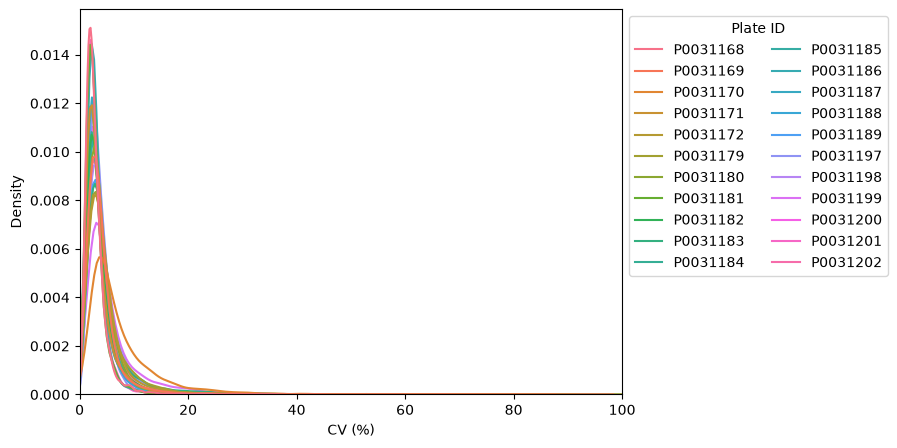

In [73]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_by_plate[calibrator_cv_by_plate.cv < 100],
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(0, 100)

plt.show()

In [68]:
calibrator_measurements_deduplicated = (
    calibrator_measurements.sort_values(["PlateId", "PlatePosition"])
                           .drop_duplicates(["PlateId", "SeqId"])
)
calibrator_measurements_deduplicated

,PlateId,PlatePosition,SeqId,value
0,P0031168,A9,10000-28,893.2555
1,P0031168,A9,10001-7,403.4078
2,P0031168,A9,10003-15,227.4742
3,P0031168,A9,10006-25,841.5257
4,P0031168,A9,10008-43,743.2851
...,...,...,...,...
699643,P0031202,A9,9993-11,1709.2900
699644,P0031202,A9,9994-217,2076.2660
699645,P0031202,A9,9995-6,2370.9650
699646,P0031202,A9,9997-12,7409.7340


In [69]:
calibrator_cv_across_plates = (
    100 * calibrator_measurements_deduplicated.groupby("SeqId").value.std() / calibrator_measurements_deduplicated.groupby("SeqId").value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_across_plates

,SeqId,cv
0,10000-28,1.649686
1,10001-7,1.824844
2,10003-15,5.187689
3,10006-25,1.746308
4,10008-43,1.527489
...,...,...
7283,9993-11,3.405568
7284,9994-217,1.591657
7285,9995-6,2.003880
7286,9997-12,4.045927


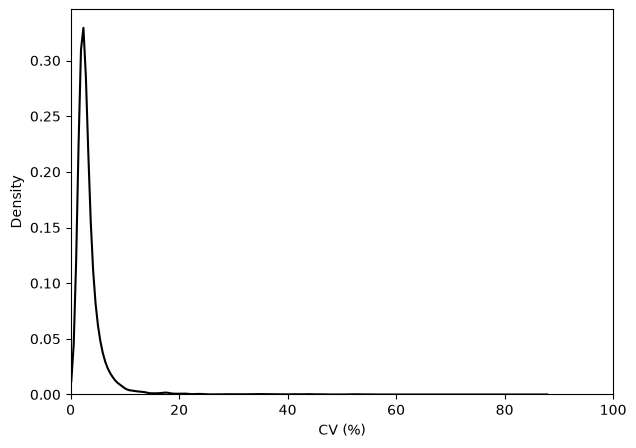

In [74]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_across_plates[calibrator_cv_across_plates.cv < 100],
    x="cv",
    c = "black"
)

plt.xlabel("CV (%)")
plt.xlim(0, 100)
plt.show()

### Sample Dispersion

In [75]:
sample_measurements = (
    samples.loc[samples.SampleType == "Sample", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

<Axes: xlabel='Replication', ylabel='count'>

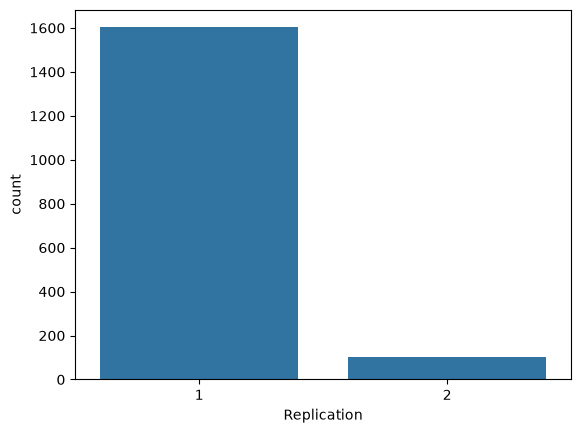

In [97]:
sns.barplot(
    data = (
        samples.loc[samples.SampleType == "Sample", :]
               .SampleId
               .value_counts()
               .rename("Replication")
               .value_counts()
               .to_frame()
    ),
    x = "Replication",
    y = "count"
)

In [104]:
replicated_samples = samples.loc[samples.SampleType == "Sample", :].SampleId.value_counts().to_frame().reset_index()
replicated_samples = replicated_samples[replicated_samples["count"] > 1]

In [107]:
samples.merge(replicated_samples).sort_values("SampleId")

,PlateId,PlateRunDate,ScannerID,PlatePosition,SlideId,Subarray,SampleId,SampleType,PercentDilution,SampleMatrix,...,CLI,RMA,SF_hyb,SF_msnCal_d0_005,SF_msnCal_d0_5,SF_msnCal_d20,SF_msnAll_d0_005,SF_msnAll_d0_5,SF_msnAll_d20,count
0,P0031168,2021-12-03,SG12344217,B8,258633829471,2,1073-17,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,0.983987,1.0,1.0,1.0,1.054723,1.037546,0.987915,2
161,P0031202,2021-12-07,SG16064525,G9,258633835127,7,1073-17,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,0.916700,1.0,1.0,1.0,1.093273,1.121631,1.051710,2
13,P0031171,2021-12-03,SG15214477,H9,258633829482,8,110-18,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,1.119069,1.0,1.0,1.0,0.904048,0.932079,1.013855,2
203,P0031201,2021-12-07,SG12064173,H9,258633834737,8,110-18,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,1.033941,1.0,1.0,1.0,0.975781,0.908696,0.977033,2
49,P0031187,2021-12-06,SG15474506,D7,258633833390,4,1104-12,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,1.128204,1.0,1.0,1.0,0.963088,1.006826,1.004812,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,P0031202,2021-12-07,SG16064525,F6,258633835124,6,7996-6,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,0.963134,1.0,1.0,1.0,0.943338,0.901685,0.933426,2
37,P0031183,2021-12-04,SG16064525,H4,258633833497,8,918-12,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,0.979846,1.0,1.0,1.0,1.096668,1.186792,1.187362,2
160,P0031202,2021-12-07,SG16064525,G8,258633835126,7,918-12,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,0.977138,1.0,1.0,1.0,0.961505,1.085226,1.149401,2
6,P0031170,2021-12-03,SG16064525,F7,258633829820,6,950-20,Sample,20,EDTA plasma,...,CLI8007F183,SS-217041,0.966176,1.0,1.0,1.0,0.921260,1.018803,1.115847,2


In [118]:
nonreplicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]],
    how = "left_anti"
)

In [119]:
nonreplicated_sample_cv_by_plate = (
    100 * nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.std() / nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
nonreplicated_sample_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,409.978840
1,P0031168,10001-7,25.675626
2,P0031168,10003-15,150.244754
3,P0031168,10006-25,64.958374
4,P0031168,10008-43,34.588950
...,...,...,...
153043,P0031201,9993-11,9.893751
153044,P0031201,9994-217,36.164537
153045,P0031201,9995-6,58.456396
153046,P0031201,9997-12,54.002584


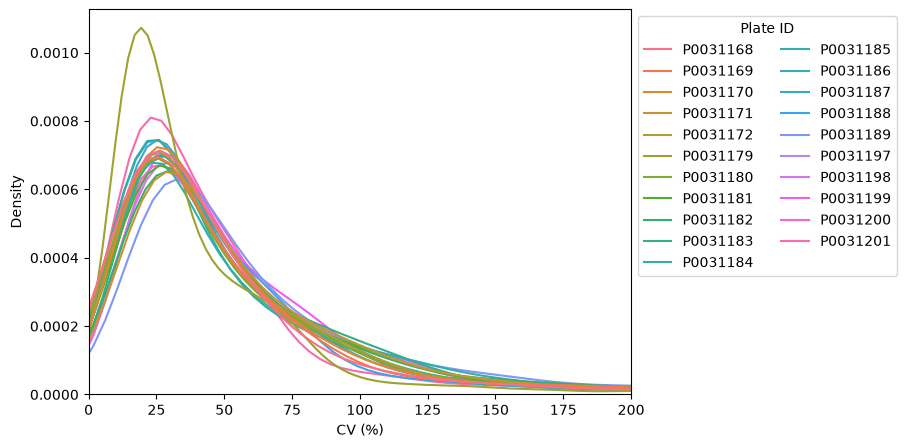

In [123]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=nonreplicated_sample_cv_by_plate,
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(0, 200)

plt.show()